In [1]:
import pandas as pd

file_path = "../data/evaluate.xlsx"
df = pd.read_excel(file_path)

In [2]:
df

,Name,MAE,RMSE,MASE,Coverage 90%,Model,Level,Is Prophet Better than?
0,Brazil,0.0559,0.0779,0.5845,0.9,Prophet,Country,1
1,Brazil,0.0559,0.0724,0.5847,0.9,ARIMA,Country,0
2,Canada,0.224,0.6237,1.0917,0.8,Prophet,Country,1
3,Canada,0.2636,0.6778,1.2845,0.8,ARIMA,Country,0
4,East Asia & Pacific,0.3277,0.3494,0.1844,1.0,Prophet,Region,1
5,East Asia & Pacific,1.1538,1.1693,0.6495,1.0,ARIMA,Region,0
6,Europe & Central Asia,0.7477,1.0884,0.3181,0.6,Prophet,Region,1
7,Europe & Central Asia,2.5299,3.6614,1.0762,0.8,ARIMA,Region,0
8,France,2.0688,2.4165,0.5314,1.0,ARIMA,Country,1
9,France,6.8212,9.5491,1.7521,0.8,Prophet,Country,0


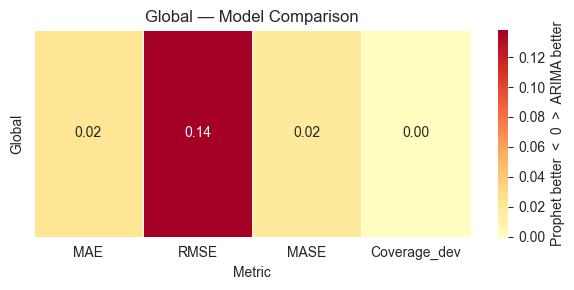

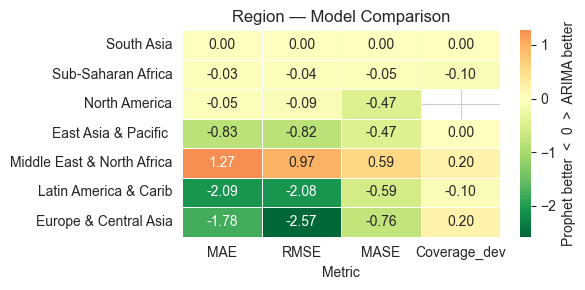

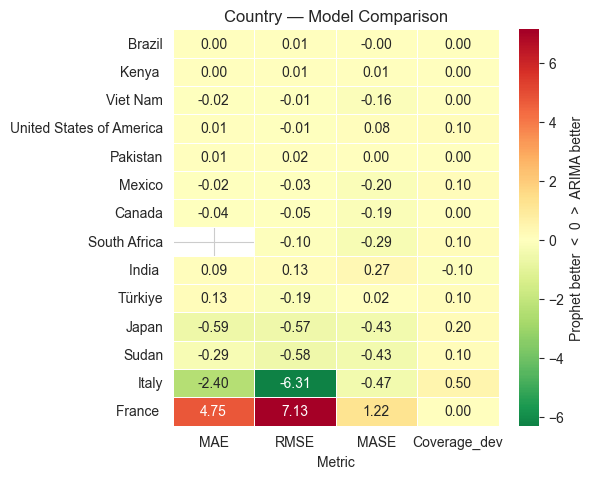

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===== Chuẩn hoá numeric =====
num_cols = ["MAE", "RMSE", "MASE", "Coverage 90%"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["Coverage_dev"] = (df["Coverage 90%"] - 0.9).abs()

metrics = ["MAE", "RMSE", "MASE", "Coverage_dev"]

# ===== Tạo bảng diff =====
diff_tables = {}

for m in metrics:
    pivot = df.pivot(index="Name", columns="Model", values=m)
    diff = pivot["Prophet"] - pivot["ARIMA"]
    diff_tables[m] = diff

# ===== Hàm vẽ =====
def plot_level(level_name):
    names = df[df["Level"] == level_name]["Name"].unique()
    data = pd.DataFrame({m: diff_tables[m].loc[names] for m in metrics})

    # sort theo RMSE magnitude
    data = data.reindex(data["RMSE"].abs().sort_values().index)

    plt.figure(figsize=(6, max(3, len(data)*0.35)))
    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        center=0,
        cmap="RdYlGn_r",
        linewidths=0.5,
        cbar_kws={"label": "Prophet better  <  0  >  ARIMA better"}
    )
    plt.title(f"{level_name} — Model Comparison")
    plt.xlabel("Metric")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

# ===== Vẽ =====
plot_level("Global")
plot_level("Region")
plot_level("Country")

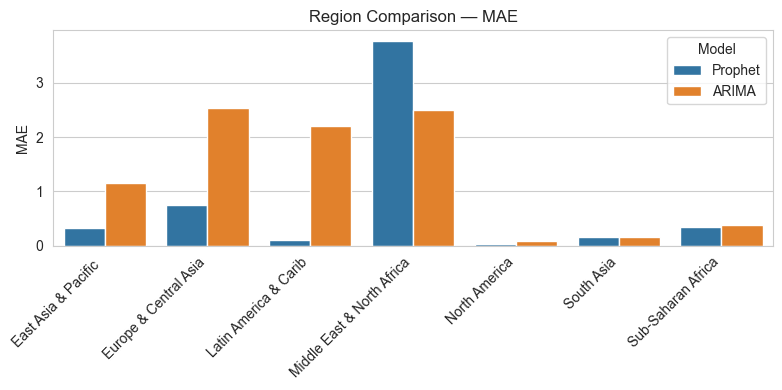

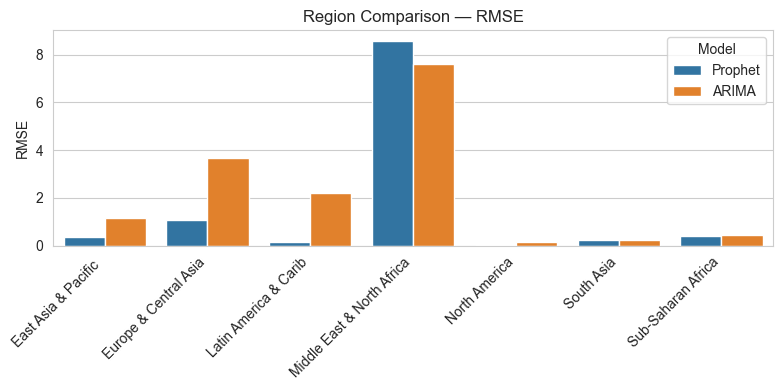

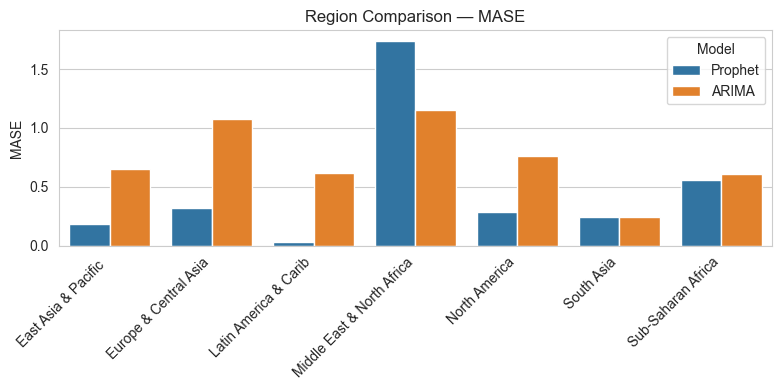

In [4]:
def plot_region_bar(metric):
    subset = df[df["Level"] == "Region"]

    plt.figure(figsize=(8,4))
    sns.barplot(
        data=subset,
        x="Name",
        y=metric,
        hue="Model"
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Region Comparison — {metric}")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

plot_region_bar("MAE")
plot_region_bar("RMSE")
plot_region_bar("MASE")

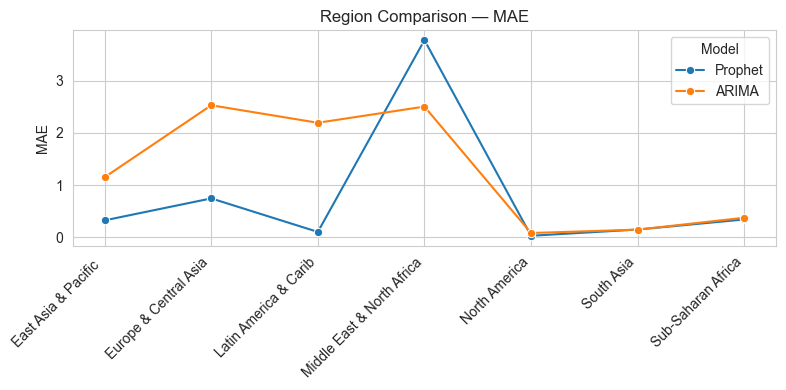

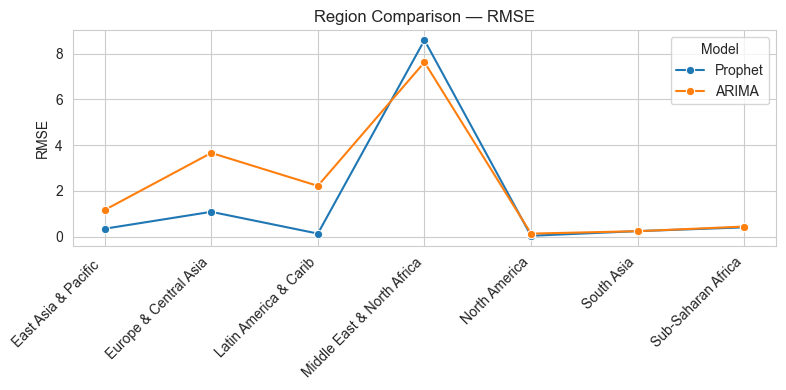

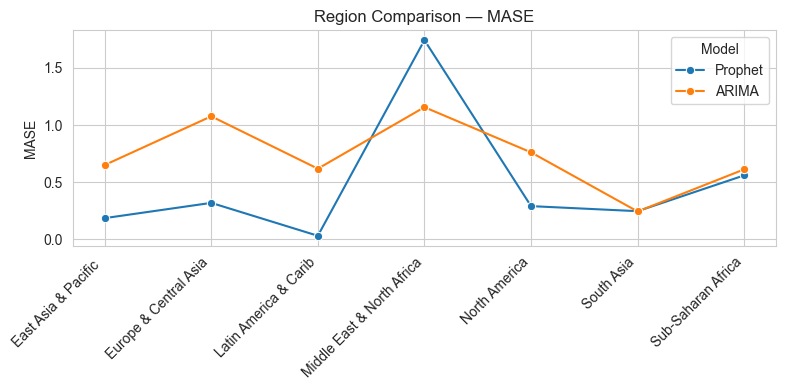

In [5]:
def plot_region_line(metric):
    subset = df[df["Level"] == "Region"]

    plt.figure(figsize=(8,4))
    sns.lineplot(
        data=subset,
        x="Name",
        y=metric,
        hue="Model",
        marker="o"
    )

    plt.xticks(rotation=45, ha="right")
    plt.title(f"Region Comparison — {metric}")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

plot_region_line("MAE")
plot_region_line("RMSE")
plot_region_line("MASE")

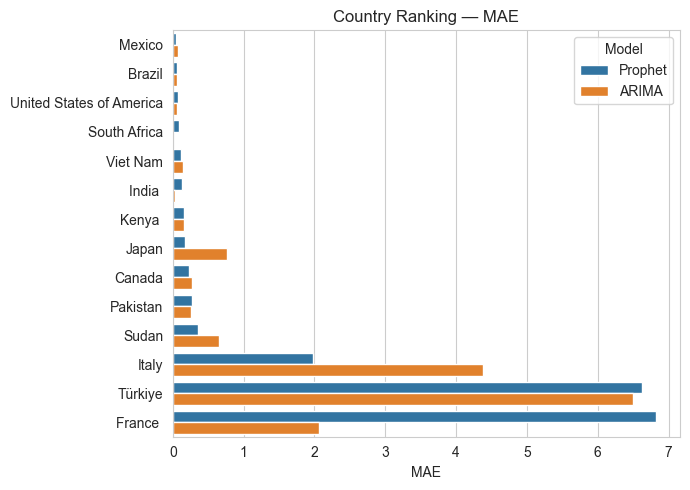

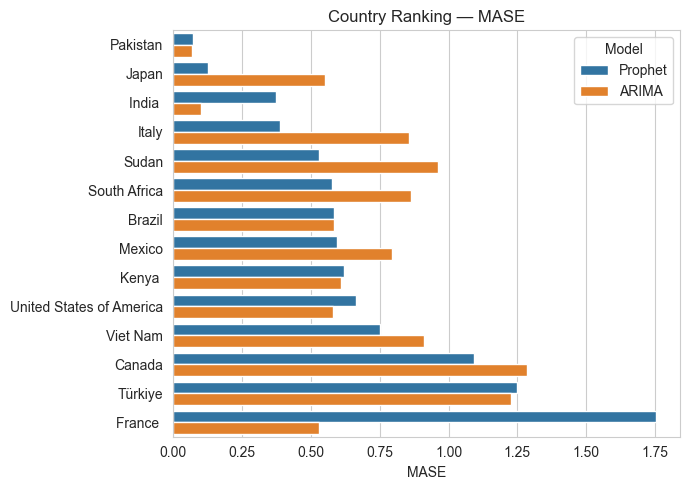

In [6]:
def plot_country_ranking(metric="MASE"):
    subset = df[df["Level"] == "Country"]

    order = (
        subset[subset["Model"] == "Prophet"]
        .sort_values(metric)["Name"]
    )

    plt.figure(figsize=(7,5))
    sns.barplot(
        data=subset,
        y="Name",
        x=metric,
        hue="Model",
        order=order
    )
    plt.title(f"Country Ranking — {metric}")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

plot_country_ranking("MAE")
plot_country_ranking("MASE")

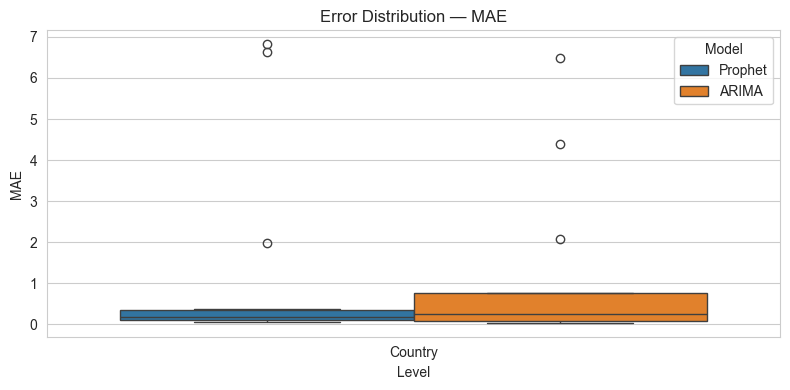

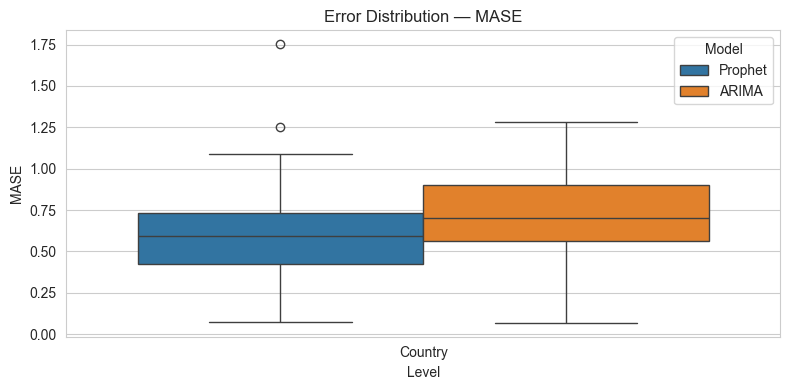

In [7]:
def plot_error_distribution(metric="MASE"):
    subset = df[df["Level"] == "Country"]

    plt.figure(figsize=(8,4))
    sns.boxplot(
        data=subset,
        x="Level",
        y=metric,
        hue="Model"
    )
    plt.title(f"Error Distribution — {metric}")
    plt.tight_layout()
    plt.show()

plot_error_distribution("MAE")
plot_error_distribution("MASE")